In [1]:
%cd ..

/Users/eli/AnacondaProjects/captcha-numpyro


In [2]:
import hydra
import jax.numpy as jnp
import numpyro
import matplotlib.pyplot as plt

In [3]:
from src.model import model

In [4]:
with hydra.initialize(version_base="1.3", config_path="../configs/", job_name="eval"):
    cfg = hydra.compose(config_name="model/captcha_generator.yaml", return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    captcha_model = hydra.utils.instantiate(cfg.model)

/Users/eli/AnacondaProjects/captcha-numpyro/.venv/lib/python3.13/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'model/captcha_generator.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


In [5]:
# captcha_model.keywords["placements"].prior.u_init.shape

In [6]:
# jnp.exp(captcha_model.keywords["placements"].prior.u_init).sum()

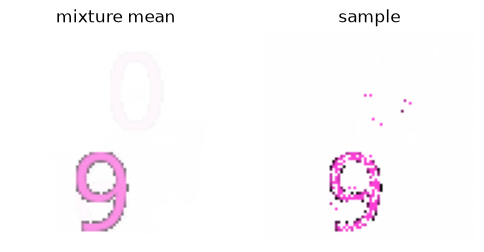

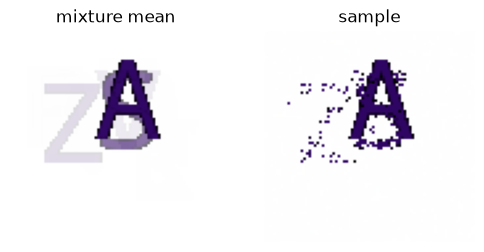

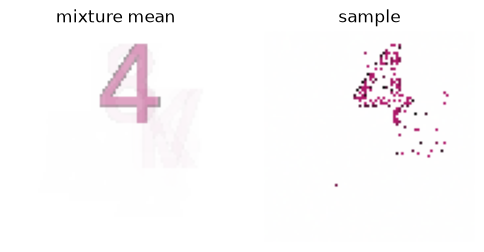

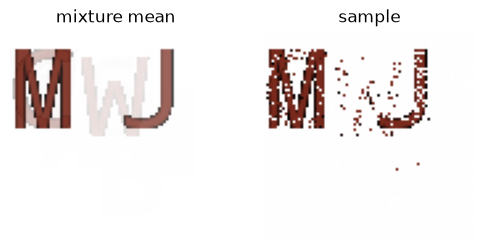

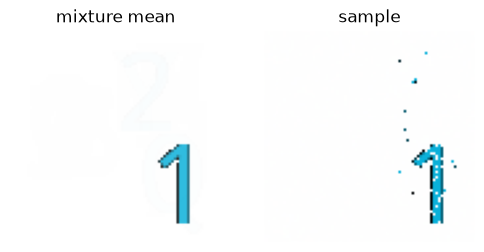

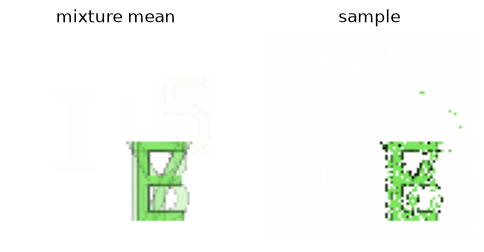

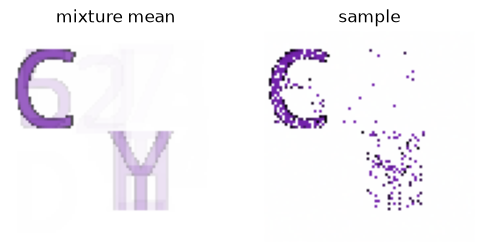

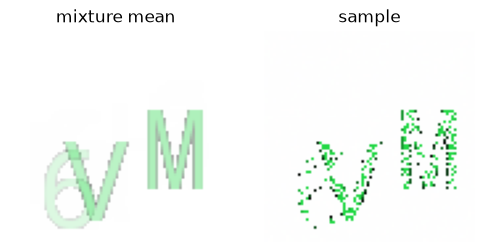

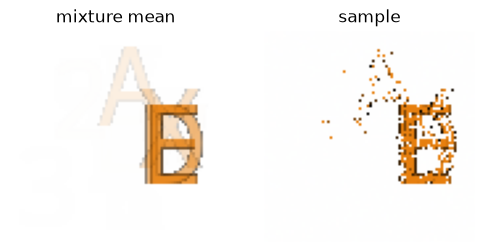

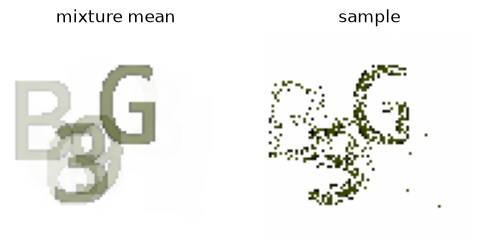

In [7]:
for i in range(10):
    with numpyro.handlers.seed(rng_seed=i):
        trace = numpyro.handlers.trace(
            lambda: captcha_model(None, scale=1e-3)
        ).get_trace()

    # ``obs`` is a per-pixel categorical draw over the background and the K
    # glyph components, so it dithers even a firmly placed glyph. Plot it next
    # to the mixture mean, which shows the placement geometry directly.
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    for ax, site, title in zip(axes, ("mean", "obs"), ("mixture mean", "sample")):
        ax.imshow(jnp.clip(trace[site]["value"][0], 0., 1.), vmin=0., vmax=1.)
        ax.set_title(title)
        ax.axis("off")
    plt.show()